In [1]:
import numpy as np
# import sympy as smp 
import matplotlib.pyplot as plt 

1. Implement a leaky integrate-and-ﬁre function.

In [2]:
def LIF(um_0, I, end_time):          
                                   
    time = 0   #s
    delta_t = 1e-6  #s
    um_t = np.zeros((int(end_time//delta_t))) 
    um_t[0] = um_0  #mV membrane potential

    Rm = 10*1e6     # Resistance (Mega Ohm) 
    Cm = 1*1e-9     # Membrane capacitance (Nano Farad)
    u_rest = -70*1e-3   # mV
    
    u_thresh = -50*1e-3             # Spiking threshold (milli Volt)
    
    for i in range(len(um_t)-1):
        #d_um_t = smp.diff((u_rest - um_t[i] + Rm*I)/(Rm*Cm),time)
        d_um_t = (u_rest - um_t[i] + Rm * I)/(Rm*Cm) * delta_t
        
        um_t[i+1] = um_t[i] + d_um_t

        if um_t[i] > u_thresh: 
            um_t[i+1] = u_rest

        time += delta_t
    
    return um_t   #voltage across the resistor (membrane potential)


In [3]:
membrane_potential = LIF(-70e-3,2.1e-9,0.1)
print(f"LIF Result: {membrane_potential}")

LIF Result: [-0.07       -0.0699979  -0.0699958  ... -0.0578311  -0.05783021
 -0.05782933]


Here the function is implemented, not much to say about it.

2. Use your function to simulate the LIF with I = 1 nA for 100 ms

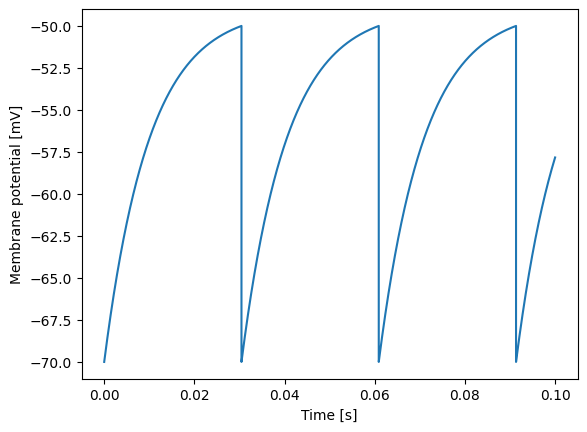

In [4]:
plt.plot(list(np.arange(0,0.1,1e-6)[:-1]), 1000*membrane_potential)
#plt.plot(membrane_potential)
plt.xlabel("Time [s]")
plt.ylabel("Membrane potential [mV]")
plt.show()

Minimum spike required is 2 nA TODO: explain why

3. Write a function to calculate the inter-spike intervals (ISI) from the plotted values.

In [5]:
def calculate_isi(um_t):
    delta_t = 1e-6      #s
    u_rest = -70*1e-3   # V
    ix = np.where(um_t == u_rest)[0]
    if len(ix) > 1:
        interval = (ix[1]-ix[0])*delta_t
        frequency = 1/interval
    else: 
        interval = 0
        frequency = 0 

    return interval, frequency

In [6]:
data = calculate_isi(membrane_potential)
print(data)
print("Interval: ", data[0]) #0.030445
print("Freq.: ", data[1])    #32.84611594678929

(0.030445, 32.84611594678929)
Interval:  0.030445
Freq.:  32.84611594678929


The interval is 0.031 making the frequency 32.85 as shown above.

4. Run a series of experiments to plot the spiking frequency as function of the constant input current for currents in the range 0-5 nA.

In [7]:
current = np.arange(1e-10,5e-9,1e-10)
spikeFreq = np.zeros(len(current))
for i, val in enumerate(current): 
    um = LIF(-70e-3,val,0.1)
    spikeFreq[i] = calculate_isi(um)[1]

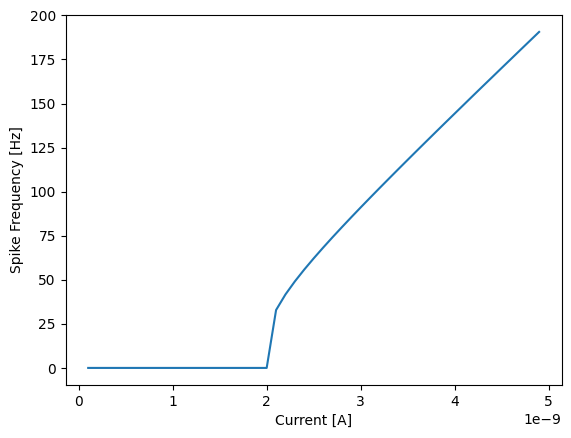

In [10]:
plt.plot(current, spikeFreq)
plt.ylabel("Spike Frequency [Hz]")
plt.xlabel("Current [A]")
plt.show()

TODO: explain the plot above and how it shows that the minimum current needed to create a spike is 2 nA.